# Customer Intelligence System

## Project Overview
This notebook implements a Customer Intelligence System using classification, ensemble models, and unsupervised clustering. In customer relationship management (CRM), understanding customer behavior, predicting churn, and segmenting customers are critical for targeted marketing and retention strategies.

The objectives of this project are:
1. Explore demographic and behavioral data of 1,000 customers.
2. Engineer composite indicators to capture overall customer value and loyalty.
3. Classify customers into value segments ('Low-Value', 'Mid-Value', 'High-Value') using Random Forest and XGBoost.
4. Group customers using unsupervised learning techniques (K-Means and DBSCAN) based on their RFM (Recency, Frequency, Monetary) metrics.
5. Identify high-risk and high-value customer segments for targeted retention campaigns.

### Dataset Features

| Feature | Description |
|---|---|
| `CustomerID` | Unique identifier for each customer |
| `Age` | Age of the customer |
| `Annual_Income` | Annual income in USD |
| `Spending_Score` | Spending score (1 to 100) assigned based on purchasing behavior |
| `Recency` | Days since the last purchase |
| `Frequency` | Number of purchases made in the last year |
| `Monetary` | Total spend in the last year in USD |
| `Churn` | Churn status (1 if churned, 0 if active) |
| `Segment` | Customer value segment ('Low-Value', 'Mid-Value', 'High-Value') |


## 1. Setup and Imports

This section imports the libraries required for data manipulation, visualization, preprocessing, classification, and clustering.


In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
PALETTE = 'viridis'

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Data Loading and Initial Inspection

Load the dataset and perform a basic check on its shape, columns, and value ranges.


In [2]:
df = pd.read_csv('Customer-data.csv')

print(f"Shape: {df.shape[0]} customers, {df.shape[1]} features\n")
df.head(10)


Shape: 1000 customers, 9 features



,CustomerID,Age,Annual_Income,Spending_Score,Recency,Frequency,Monetary,Churn,Segment
0,1001,56,24838,63,35,19,1153.29,0,Mid-Value
1,1002,69,70086,36,62,14,2039.42,1,Mid-Value
2,1003,46,46091,47,165,14,1556.24,0,Low-Value
3,1004,32,29443,59,3,16,1349.53,0,Mid-Value
4,1005,60,48835,19,104,7,1043.48,0,Low-Value
5,1006,25,37961,22,20,10,732.44,0,Low-Value
6,1007,38,107178,36,35,9,2265.72,0,Low-Value
7,1008,56,87040,68,1,22,4590.88,0,High-Value
8,1009,36,64800,42,21,9,1241.22,0,Low-Value
9,1010,40,101998,95,41,28,6357.25,0,High-Value


In [3]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Data Types:
CustomerID          int64
Age                 int64
Annual_Income       int64
Spending_Score      int64
Recency             int64
Frequency           int64
Monetary          float64
Churn               int64
Segment               str
dtype: object

Missing Values:
CustomerID        0
Age               0
Annual_Income     0
Spending_Score    0
Recency           0
Frequency         0
Monetary          0
Churn             0
Segment           0
dtype: int64

Duplicate Rows:
0


In [4]:
df.describe().T.style.background_gradient(cmap='YlOrRd', axis=1)


,count,mean,std,min,25%,50%,75%,max
CustomerID,1000.000000,1500.500000,288.819436,1001.000000,1250.750000,1500.500000,1750.250000,2000.000000
Age,1000.000000,43.819000,14.991030,18.000000,31.000000,44.000000,56.000000,69.000000
Annual_Income,1000.000000,66603.491000,24309.399425,15000.000000,49704.000000,66345.500000,82136.500000,130809.000000
Spending_Score,1000.000000,48.984000,15.822266,1.000000,39.000000,49.000000,60.000000,100.000000
Recency,1000.000000,57.293000,57.741781,1.000000,16.000000,39.500000,80.250000,365.000000
Frequency,1000.000000,15.080000,4.136267,2.000000,12.000000,15.000000,18.000000,28.000000
Monetary,1000.000000,2395.153410,1222.797411,181.830000,1503.692500,2228.765000,3031.327500,6674.260000
Churn,1000.000000,0.125000,0.330884,0.000000,0.000000,0.000000,0.000000,1.000000


### Initial Observations:
- There are no missing values or duplicate rows in the dataset.
- Customer age ranges from 18 to 69 years, indicating a diverse adult customer base.
- Annual income exhibits a broad distribution from $15,000 to $150,000.
- Spending score, recency, frequency, and monetary values span standard behavioral ranges, offering rich signals for segmentation and predictive modeling.


## 3. Exploratory Data Analysis (EDA)

Explore feature distributions and analyze correlations to understand customer characteristics.


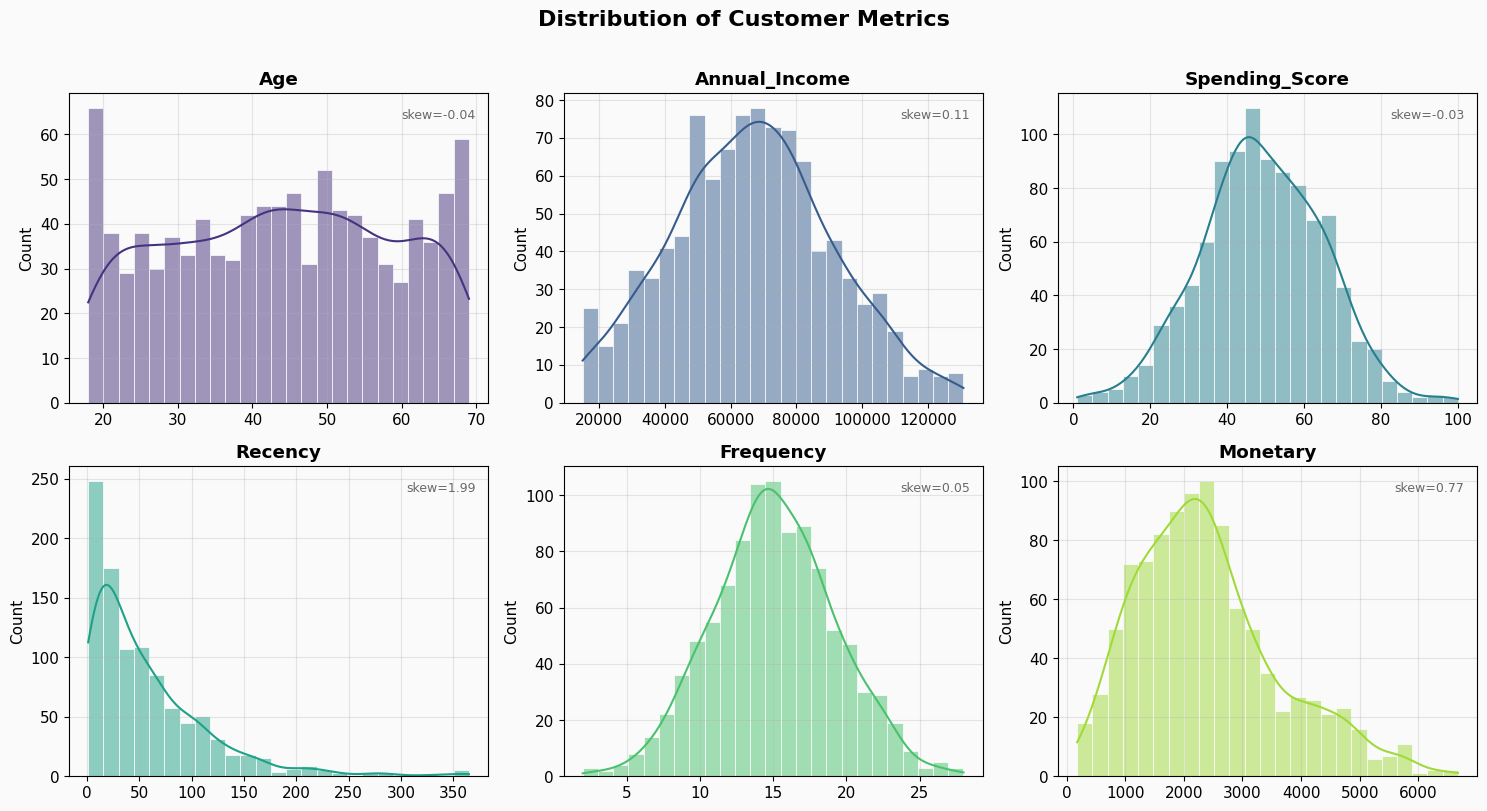

In [5]:
numeric_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Recency', 'Frequency', 'Monetary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Customer Metrics', fontsize=16, fontweight='bold', y=1.01)

colors = sns.color_palette('viridis', len(numeric_cols))

for ax, col, color in zip(axes.flat, numeric_cols, colors):
    sns.histplot(df[col], ax=ax, kde=True, color=color, bins=25, edgecolor='white', linewidth=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    skew = df[col].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='dimgray')

plt.tight_layout()
plt.show()


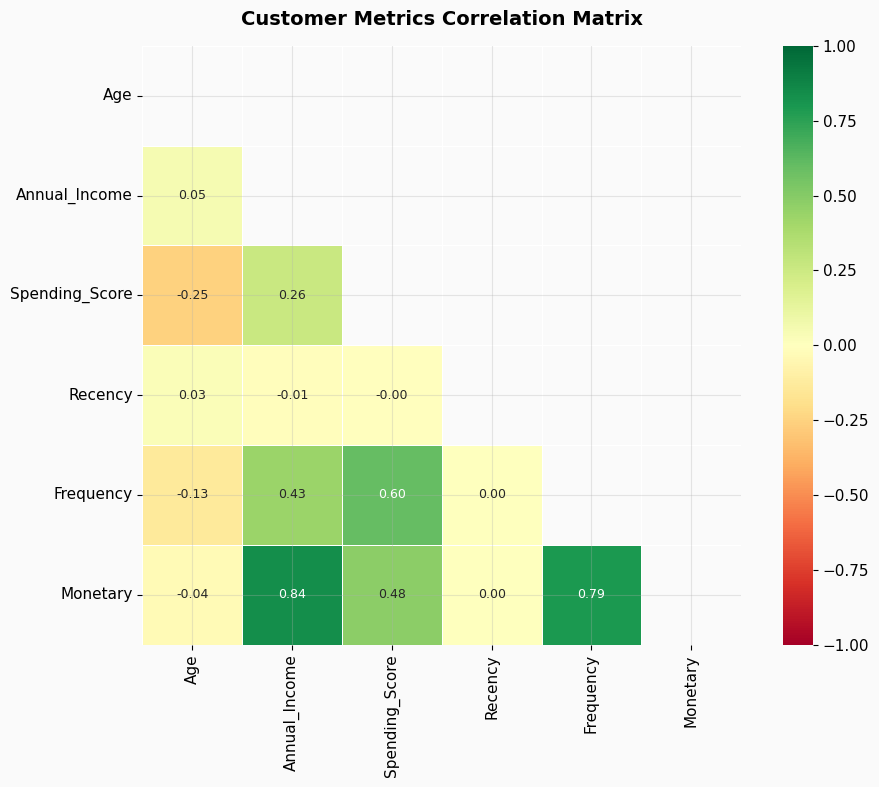

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=-1, vmax=1, center=0, square=True, ax=ax,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title('Customer Metrics Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### Correlation Observations:
- Monetary value and frequency show a very high positive correlation, as expected since more frequent purchases drive total spend.
- Spending score shows moderate positive correlation with frequency and monetary value.
- Age and recency show negligible correlation with other features, suggesting they provide independent dimensions for clustering.


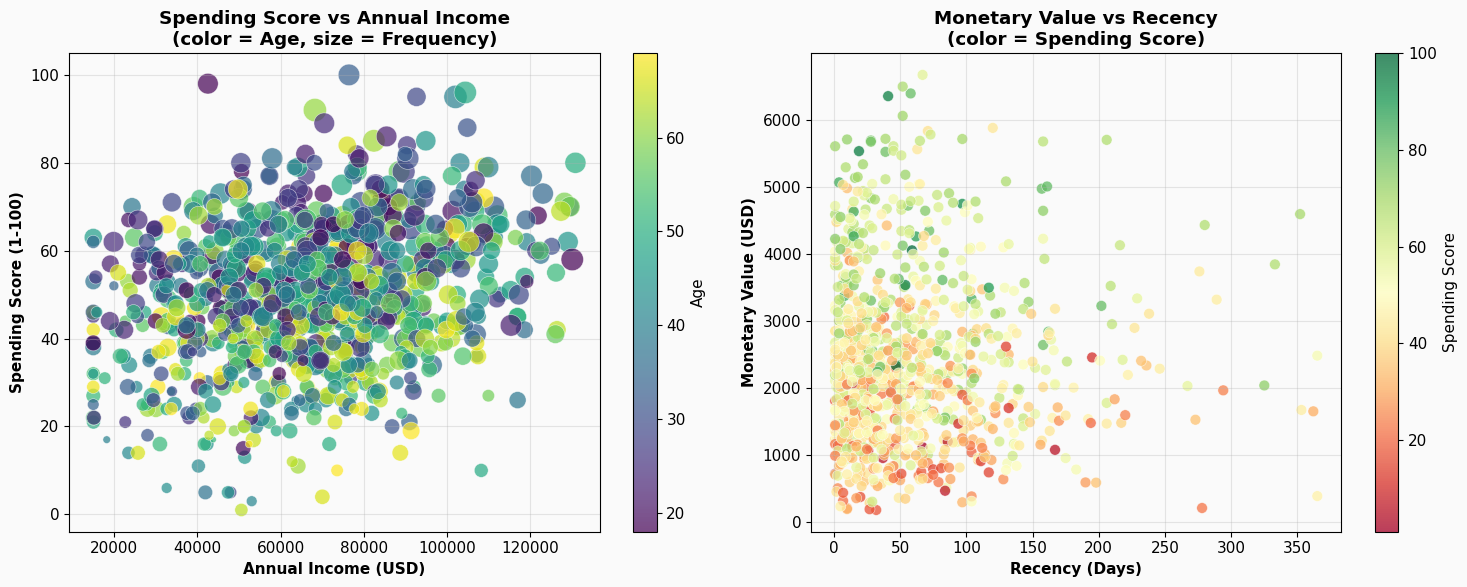

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(
    df['Annual_Income'], df['Spending_Score'],
    c=df['Age'], cmap='viridis',
    s=df['Frequency']*10, alpha=0.7, edgecolors='white', linewidth=0.4
)
axes[0].set_xlabel('Annual Income (USD)', fontweight='bold')
axes[0].set_ylabel('Spending Score (1-100)', fontweight='bold')
axes[0].set_title('Spending Score vs Annual Income\n(color = Age, size = Frequency)', fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='Age')

sc2 = axes[1].scatter(
    df['Recency'], df['Monetary'],
    c=df['Spending_Score'], cmap='RdYlGn',
    s=60, alpha=0.75, edgecolors='white', linewidth=0.4
)
axes[1].set_xlabel('Recency (Days)', fontweight='bold')
axes[1].set_ylabel('Monetary Value (USD)', fontweight='bold')
axes[1].set_title('Monetary Value vs Recency\n(color = Spending Score)', fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Spending Score')

plt.tight_layout()
plt.show()


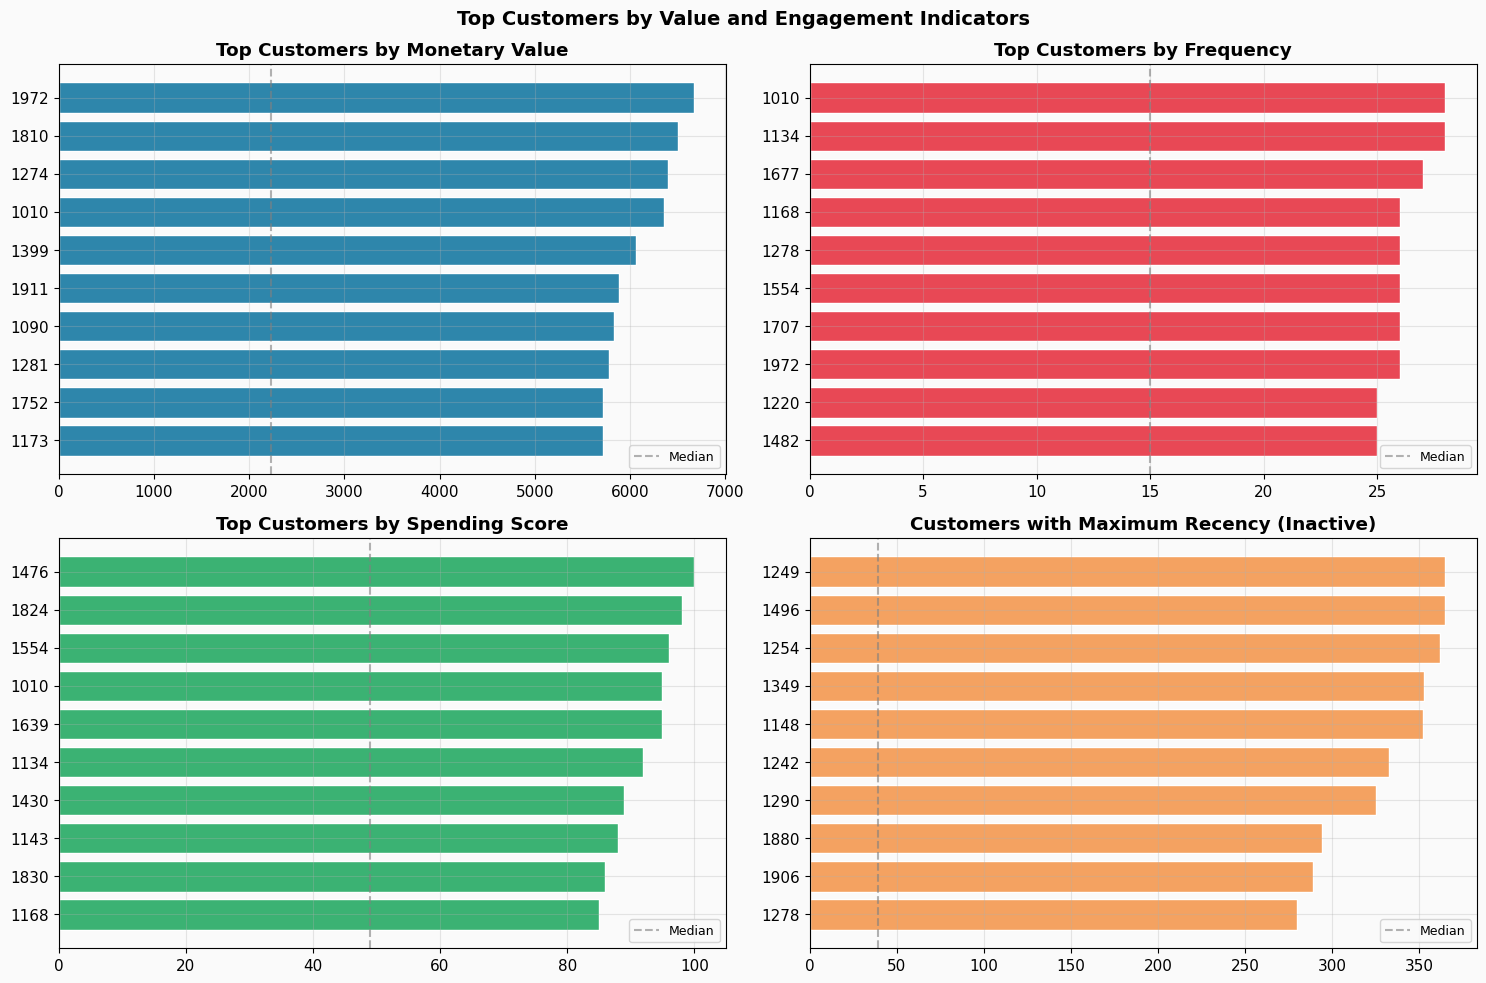

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Top Customers by Value and Engagement Indicators', fontsize=14, fontweight='bold')

indicators = [
    ('Monetary', 'Top Customers by Monetary Value', '#2E86AB'),
    ('Frequency', 'Top Customers by Frequency', '#E84855'),
    ('Spending_Score', 'Top Customers by Spending Score', '#3BB273'),
    ('Recency', 'Customers with Maximum Recency (Inactive)', '#F4A261'),
]

for ax, (col, title, color) in zip(axes.flat, indicators):
    top10 = df.nlargest(10, col)[['CustomerID', col]].reset_index(drop=True)
    ax.barh(top10['CustomerID'].astype(str), top10[col], color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    ax.axvline(df[col].median(), color='gray', linestyle='--', alpha=0.6, label='Median')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 4. Feature Engineering

To better capture customer profiles and prepare inputs for modeling:
- **Log Transformations**: Applied to right-skewed columns (`Monetary` and `Annual_Income`) to stabilize variance.
- **Loyalty Score**: A composite indicator built by combining normalized spending score, frequency, and inverse recency.


In [9]:
df_feat = df.copy()

df_feat['log_Monetary'] = np.log1p(df_feat['Monetary'])
df_feat['log_Income'] = np.log1p(df_feat['Annual_Income'])

def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

freq_idx = min_max(df_feat['Frequency'])
spend_idx = min_max(df_feat['Spending_Score'])
rec_idx = 1 - min_max(df_feat['Recency'])

df_feat['loyalty_score'] = (freq_idx + spend_idx + rec_idx) / 3

print("Feature engineering complete.")
print(f"\nNew features added: log_Monetary, log_Income, loyalty_score")
print(f"\nCustomer Segment Distribution:")
print(df_feat['Segment'].value_counts())


Feature engineering complete.

New features added: log_Monetary, log_Income, loyalty_score

Customer Segment Distribution:
Segment
High-Value    340
Mid-Value     330
Low-Value     330
Name: count, dtype: int64


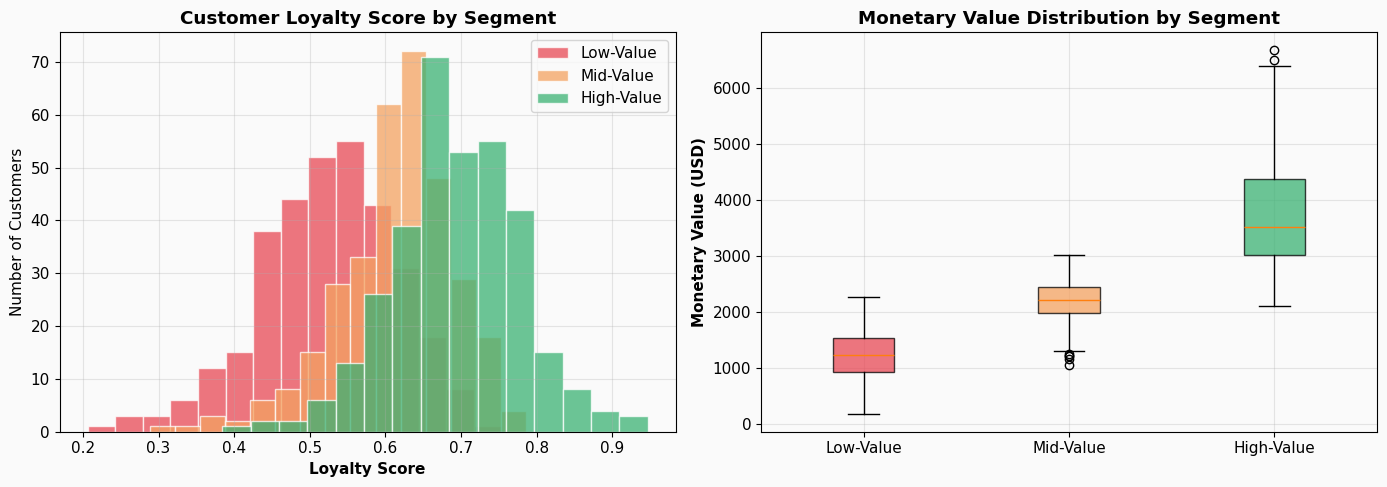

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_order = ['Low-Value', 'Mid-Value', 'High-Value']
segment_colors = {'Low-Value': '#E84855', 'Mid-Value': '#F4A261', 'High-Value': '#3BB273'}

for seg in segment_order:
    subset = df_feat[df_feat['Segment'] == seg]['loyalty_score']
    axes[0].hist(subset, bins=15, alpha=0.75, label=seg, color=segment_colors[seg], edgecolor='white')

axes[0].set_xlabel('Loyalty Score', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Loyalty Score by Segment', fontweight='bold')
axes[0].legend()

seg_data = [df_feat[df_feat['Segment'] == s]['Monetary'].values for s in segment_order]
bp = axes[1].boxplot(seg_data, labels=segment_order, patch_artist=True, notch=False)
for patch, seg in zip(bp['boxes'], segment_order):
    patch.set_facecolor(segment_colors[seg])
    patch.set_alpha(0.75)
axes[1].set_ylabel('Monetary Value (USD)', fontweight='bold')
axes[1].set_title('Monetary Value Distribution by Segment', fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Preprocessing for Modeling

Preprocessing steps include:
- Feature selection (excluding variables that would cause target leakage).
- Label encoding of the target variable (`Segment`).
- Splitting the dataset into train and test sets (80/20 stratified split).
- Scaling features using `StandardScaler` for distance-based models and clustering.


In [11]:
FEATURE_COLS = [
    'Age', 'Annual_Income', 'Spending_Score', 'Recency', 'Frequency', 'Monetary',
    'log_Monetary', 'log_Income'
]
TARGET_COL = 'Segment'

X = df_feat[FEATURE_COLS]
y_raw = df_feat[TARGET_COL]

le = LabelEncoder()
y = le.fit_transform(y_raw)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_all_sc   = scaler.transform(X)

print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Class balance (train): {dict(zip(le.classes_, np.bincount(y_train)))}")


Label mapping: {'High-Value': np.int64(0), 'Low-Value': np.int64(1), 'Mid-Value': np.int64(2)}

Train size: 800 | Test size: 200
Class balance (train): {'High-Value': np.int64(272), 'Low-Value': np.int64(264), 'Mid-Value': np.int64(264)}


## 6. Supervised Classification

We train three classification models to predict the customer segment:
1. **Logistic Regression**: A linear model serving as a baseline.
2. **Random Forest**: An ensemble method capable of capturing non-linear relationships.
3. **XGBoost**: A gradient boosting algorithm suited for tabular datasets.

Each model is evaluated using 5-fold stratified cross-validation on the training set, followed by a final evaluation on the hold-out test set.


In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8,
                                                  min_samples_leaf=2, random_state=42,
                                                  class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                         subsample=0.8, colsample_bytree=0.8,
                                         use_label_encoder=False, eval_metric='mlogloss',
                                         random_state=42, verbosity=0)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("Running 5-Fold Stratified Cross-Validation...\n")
print(f"{'Model':<25} {'CV Mean Acc':>12} {'CV Std':>10}")
print('-' * 50)

for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>10.4f}")

print()
print("Best cross-val model:", max(cv_results, key=lambda k: cv_results[k].mean()))


Running 5-Fold Stratified Cross-Validation...

Model                      CV Mean Acc     CV Std
--------------------------------------------------
Logistic Regression             0.9737     0.0108
Random Forest                   0.9613     0.0170
XGBoost                         0.9738     0.0092

Best cross-val model: XGBoost


In [13]:
results = {}

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'model':  model,
        'y_pred': y_pred,
        'acc':    acc
    }

print(f"{'Model':<25} {'Test Accuracy':>14}")
print('-' * 42)
for name, r in results.items():
    print(f"{name:<25} {r['acc']:>14.4f}")


Model                      Test Accuracy
------------------------------------------
Logistic Regression               0.9850
Random Forest                     0.9700
XGBoost                           0.9850


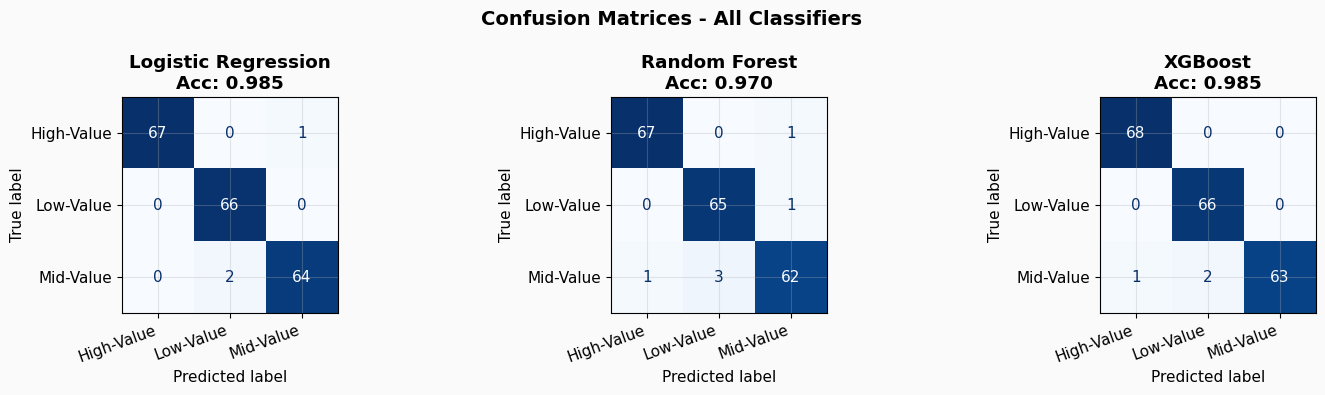

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Confusion Matrices - All Classifiers', fontsize=14, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc: {r['acc']:.3f}", fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()


### Best Model Performance Analysis

We extract the classification report and feature importances for the model that achieved the highest test accuracy.


In [15]:
best_name = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print(f"Best Model: {best_name} (Test Accuracy: {results[best_name]['acc']:.4f})\n")
print("Full Classification Report:")
print(classification_report(y_test, best_pred, target_names=le.classes_))


Best Model: Logistic Regression (Test Accuracy: 0.9850)

Full Classification Report:
              precision    recall  f1-score   support

  High-Value       1.00      0.99      0.99        68
   Low-Value       0.97      1.00      0.99        66
   Mid-Value       0.98      0.97      0.98        66

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



In [16]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
    feat_imp_df = feat_imp_df.sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 7))
    bars = ax.barh(feat_imp_df['feature'], feat_imp_df['importance'],
                   color=sns.color_palette('viridis', len(feat_imp_df)), edgecolor='white')
    ax.set_xlabel('Feature Importance Score', fontweight='bold')
    ax.set_title(f'Feature Importances - {best_name}', fontsize=13, fontweight='bold')

    for bar, val in zip(bars, feat_imp_df['importance']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


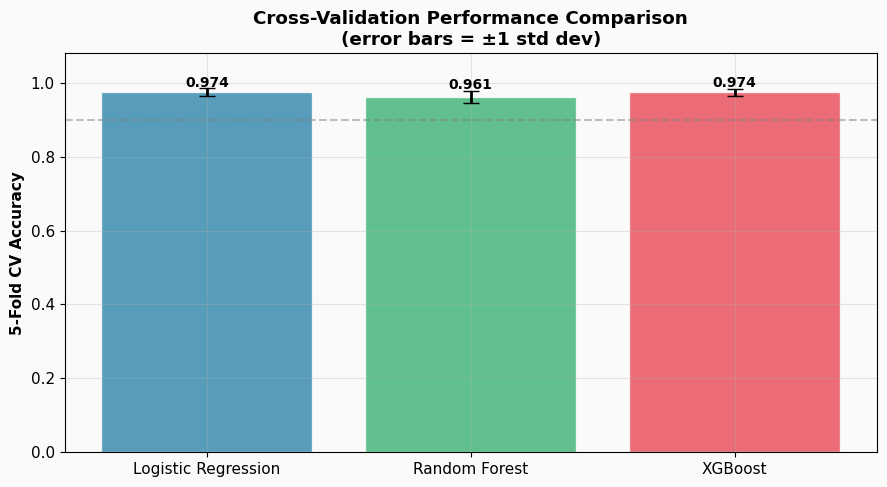

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

positions = np.arange(len(cv_results))
colors_cv = ['#2E86AB', '#3BB273', '#E84855']

for pos, (name, scores), color in zip(positions, cv_results.items(), colors_cv):
    ax.bar(pos, scores.mean(), color=color, alpha=0.8, edgecolor='white', label=name)
    ax.errorbar(pos, scores.mean(), yerr=scores.std(), fmt='none',
                color='black', capsize=6, linewidth=2)
    ax.text(pos, scores.mean() + scores.std() + 0.005,
            f'{scores.mean():.3f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels(cv_results.keys(), fontsize=11)
ax.set_ylabel('5-Fold CV Accuracy', fontweight='bold')
ax.set_title('Cross-Validation Performance Comparison\n(error bars = ±1 std dev)', fontweight='bold')
ax.set_ylim(0, 1.08)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% threshold')

plt.tight_layout()
plt.show()


## 7. Unsupervised Clustering

While classification relies on predefined categories, clustering identifies natural groupings within the data. This allows for a data-driven categorization of customers.

We implement two clustering algorithms:
- **K-Means Clustering**: A centroid-based approach.
- **DBSCAN Clustering**: A density-based clustering algorithm that identifies outliers as noise.

We evaluate the optimal number of clusters for K-Means using the Elbow Method, Silhouette Score, and Davies-Bouldin Index.


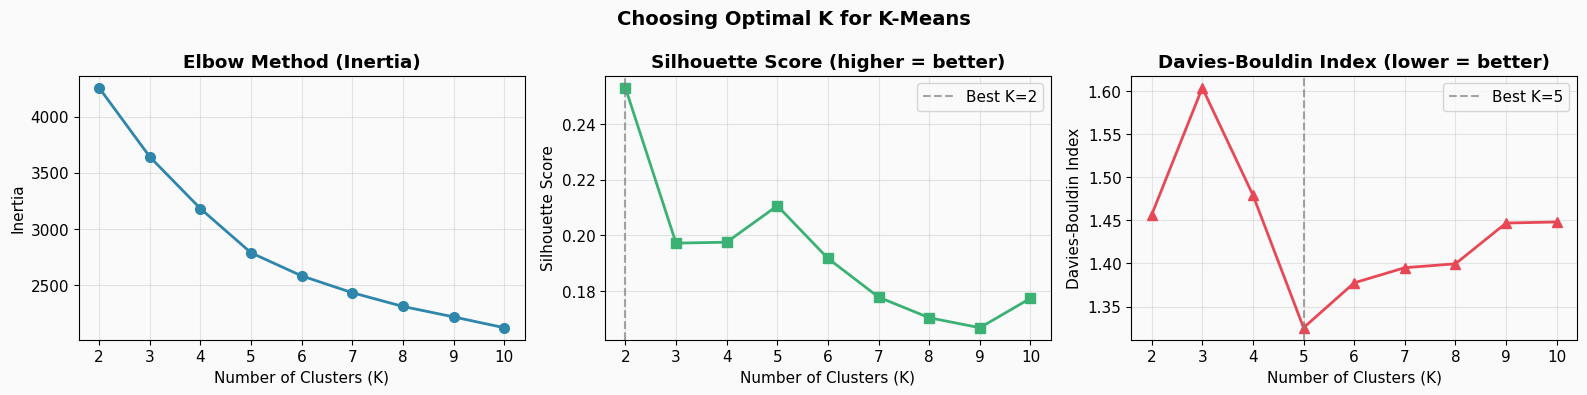


Optimal K by Silhouette:  2
Optimal K by Davies-Bouldin: 5


In [18]:
CLUSTER_COLS = ['Age', 'Annual_Income', 'Spending_Score', 'Recency', 'Frequency', 'Monetary']

X_clust = scaler.fit_transform(df_feat[CLUSTER_COLS])

inertias    = []
sil_scores  = []
db_scores   = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))
    db_scores.append(davies_bouldin_score(X_clust, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Choosing Optimal K for K-Means', fontsize=14, fontweight='bold')

axes[0].plot(K_range, inertias, 'o-', color='#2E86AB', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, 's-', color='#3BB273', linewidth=2, markersize=7)
best_k_sil = K_range[np.argmax(sil_scores)]
axes[1].axvline(best_k_sil, color='gray', linestyle='--', alpha=0.7, label=f'Best K={best_k_sil}')
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

axes[2].plot(K_range, db_scores, '^-', color='#E84855', linewidth=2, markersize=7)
best_k_db = K_range[np.argmin(db_scores)]
axes[2].axvline(best_k_db, color='gray', linestyle='--', alpha=0.7, label=f'Best K={best_k_db}')
axes[2].set_title('Davies-Bouldin Index (lower = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].legend()

plt.tight_layout()
plt.show()
print(f"\nOptimal K by Silhouette:  {best_k_sil}")
print(f"Optimal K by Davies-Bouldin: {best_k_db}")


In [19]:
OPTIMAL_K = best_k_sil

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=20)
df_feat['kmeans_cluster'] = kmeans.fit_predict(X_clust)

sil_km = silhouette_score(X_clust, df_feat['kmeans_cluster'])
db_km  = davies_bouldin_score(X_clust, df_feat['kmeans_cluster'])
print(f"K-Means (K={OPTIMAL_K}) → Silhouette: {sil_km:.4f}  |  Davies-Bouldin: {db_km:.4f}")


K-Means (K=2) → Silhouette: 0.2529  |  Davies-Bouldin: 1.4570


In [20]:
best_sil_db = -1
best_params = {}

for eps in np.arange(0.8, 2.5, 0.2):
    for min_s in [3, 4, 5, 6]:
        db_model = DBSCAN(eps=eps, min_samples=min_s)
        labels = db_model.fit_predict(X_clust)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2 and n_noise < 50:
            non_noise = labels != -1
            if non_noise.sum() > 20:
                sil = silhouette_score(X_clust[non_noise], labels[non_noise])
                if sil > best_sil_db:
                    best_sil_db = sil
                    best_params = {'eps': eps, 'min_samples': min_s,
                                   'n_clusters': n_clusters, 'n_noise': n_noise}

print("Best DBSCAN Parameters:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"  Silhouette Score: {best_sil_db:.4f}")

dbscan = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples'])
df_feat['dbscan_cluster'] = dbscan.fit_predict(X_clust)


Best DBSCAN Parameters:
  eps: 1.2
  min_samples: 3
  n_clusters: 2
  n_noise: 49
  Silhouette Score: 0.2771


PCA variance explained: PC1=45.94%, PC2=19.34%, Total=65.28%


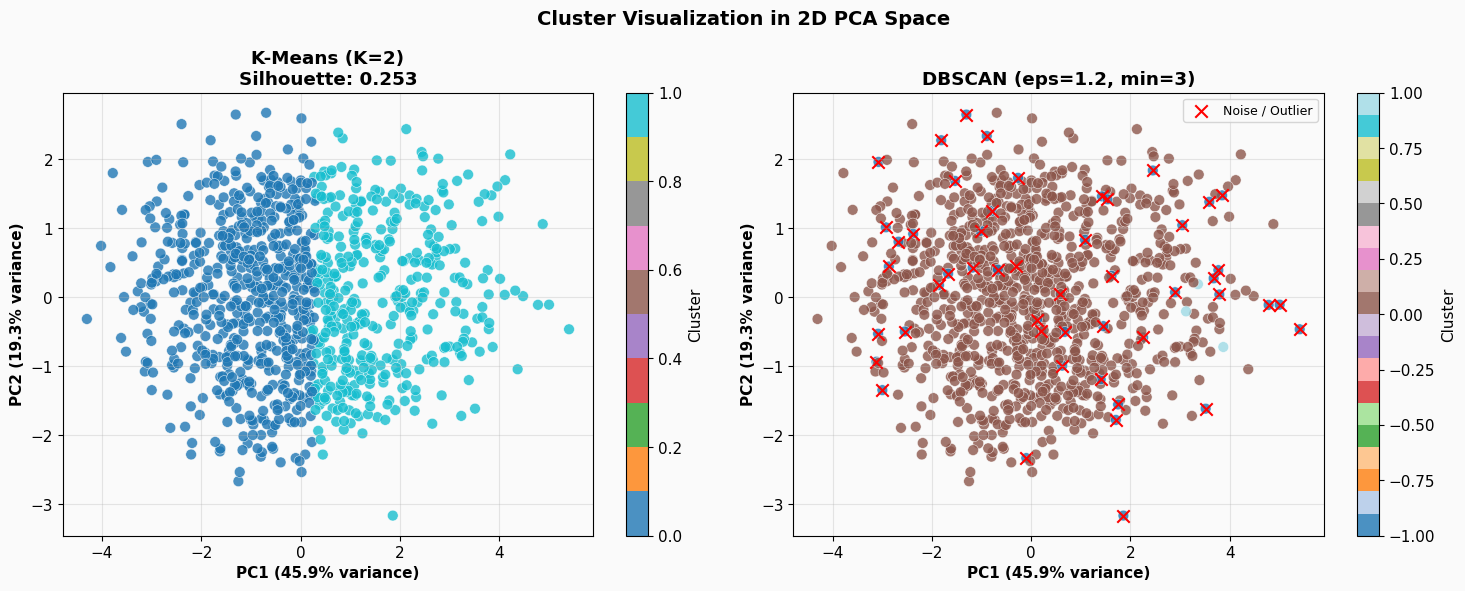

In [21]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
df_feat['pca1'] = X_pca[:, 0]
df_feat['pca2'] = X_pca[:, 1]

var_explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={var_explained[0]:.2%}, PC2={var_explained[1]:.2%}, "
      f"Total={sum(var_explained):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Cluster Visualization in 2D PCA Space', fontsize=14, fontweight='bold')

scatter1 = axes[0].scatter(
    df_feat['pca1'], df_feat['pca2'],
    c=df_feat['kmeans_cluster'], cmap='tab10', s=60, alpha=0.8, edgecolors='white', linewidth=0.4
)
axes[0].set_title(f'K-Means (K={OPTIMAL_K})\nSilhouette: {sil_km:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)', fontweight='bold')
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(
    df_feat['pca1'], df_feat['pca2'],
    c=df_feat['dbscan_cluster'], cmap='tab20', s=60, alpha=0.8, edgecolors='white', linewidth=0.4
)
noise_mask = df_feat['dbscan_cluster'] == -1
axes[1].scatter(
    df_feat.loc[noise_mask, 'pca1'], df_feat.loc[noise_mask, 'pca2'],
    marker='x', s=80, c='red', linewidth=1.5, label='Noise / Outlier'
)
axes[1].set_title(f'DBSCAN (eps={best_params["eps"]:.1f}, min={best_params["min_samples"]})',
                  fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)', fontweight='bold')
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)', fontweight='bold')
axes[1].legend(fontsize=9)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()


## 8. Cluster Profiling

We calculate the average feature values for each cluster to interpret the characteristics of each grouped customer tier.


In [22]:
profile_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Recency', 'Frequency', 'Monetary', 'loyalty_score']

cluster_profiles = df_feat.groupby('kmeans_cluster')[profile_cols].mean().round(2)
cluster_profiles['customer_count'] = df_feat.groupby('kmeans_cluster')['CustomerID'].count()

cluster_profiles = cluster_profiles.sort_values('loyalty_score', ascending=False)
print("K-Means Cluster Profiles (sorted by loyalty score):\n")
cluster_profiles.style.background_gradient(cmap='RdYlGn', axis=0)


K-Means Cluster Profiles (sorted by loyalty score):



,Age,Annual_Income,Spending_Score,Recency,Frequency,Monetary,loyalty_score,customer_count
kmeans_cluster,,,,,,,,
1,40.840000,84721.310000,59.700000,60.300000,18.500000,3529.050000,0.690000,401
0,45.810000,54474.540000,41.810000,55.280000,12.790000,1636.060000,0.560000,599


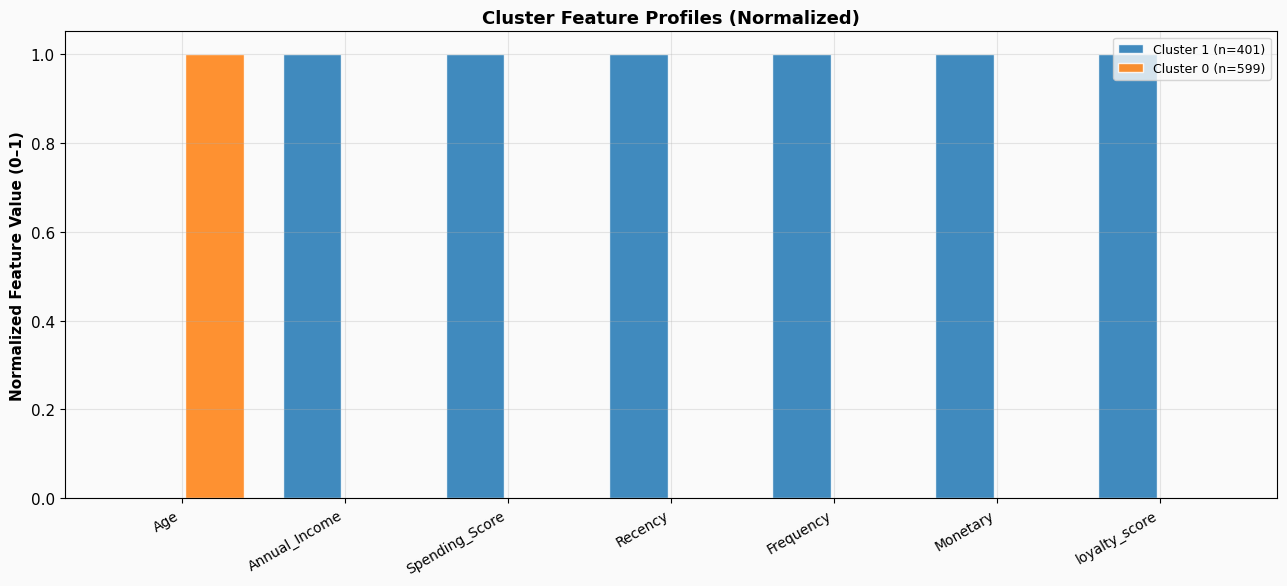

In [23]:
profile_norm = cluster_profiles[profile_cols].copy()
for col in profile_norm.columns:
    col_range = profile_norm[col].max() - profile_norm[col].min()
    if col_range > 0:
        profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / col_range

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(profile_cols))
width = 0.8 / len(cluster_profiles)
palette = sns.color_palette('tab10', len(cluster_profiles))

for i, (cluster_id, row) in enumerate(profile_norm.iterrows()):
    n = cluster_profiles.loc[cluster_id, 'customer_count']
    ax.bar(x + i * width, row[profile_cols], width=width * 0.9,
           label=f'Cluster {cluster_id} (n={n})', color=palette[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * (len(cluster_profiles) - 1) / 2)
ax.set_xticklabels(profile_cols, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Normalized Feature Value (0–1)', fontweight='bold')
ax.set_title('Cluster Feature Profiles (Normalized)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


In [24]:
print("Customers by K-Means Cluster:\n")
for cluster_id in sorted(df_feat['kmeans_cluster'].unique()):
    ids = df_feat[df_feat['kmeans_cluster'] == cluster_id]['CustomerID'].sort_values().tolist()
    score_mean = df_feat[df_feat['kmeans_cluster'] == cluster_id]['loyalty_score'].mean()
    print(f"  Cluster {cluster_id} (Loyalty Score: {score_mean:.3f}, n={len(ids)}):")
    print(f"    {', '.join(map(str, ids[:12]))}{' ...' if len(ids) > 12 else ''}")
    print()


Customers by K-Means Cluster:

  Cluster 0 (Loyalty Score: 0.559, n=599):
    1001, 1002, 1003, 1004, 1005, 1006, 1007, 1009, 1011, 1012, 1016, 1018 ...

  Cluster 1 (Loyalty Score: 0.688, n=401):
    1008, 1010, 1013, 1014, 1015, 1017, 1019, 1020, 1027, 1034, 1035, 1038 ...



## 9. Identifying Priority Customers for Retention

To target customers for targeted marketing and retention campaigns, we compute a Retention Priority Score. This score combines high churn flag, high spending score, and high overall monetary value to pinpoint valuable customers at risk of leaving.


In [25]:
df_feat['priority_score'] = (
    df_feat['Churn']
    + min_max(df_feat['Monetary'])
    + min_max(df_feat['Spending_Score'])
) / 3

top_priority = df_feat.nlargest(20, 'priority_score')[[
    'CustomerID', 'Age', 'Annual_Income', 'Spending_Score', 'Recency', 
    'Frequency', 'Monetary', 'Churn', 'priority_score'
]].reset_index(drop=True)

print("Top 20 Customers with Highest Retention Priority Score:\n")
top_priority.style.background_gradient(cmap='Reds', subset=['priority_score']) \
                  .background_gradient(cmap='Greens', subset=['Monetary', 'Annual_Income'])


Top 20 Customers with Highest Retention Priority Score:



,CustomerID,Age,Annual_Income,Spending_Score,Recency,Frequency,Monetary,Churn,priority_score
0,1795,35,122983,73,10,23,5710.490000,1,0.859609
1,1160,66,106725,71,1,23,5609.420000,1,0.847686
2,1141,54,112050,68,206,23,5704.710000,1,0.842477
3,1533,54,108399,66,158,22,5680.570000,1,0.834504
4,1148,31,92354,70,352,21,4596.820000,1,0.792330
5,1728,20,108739,64,78,21,4883.060000,1,0.786824
6,1930,21,78905,81,82,19,3614.150000,1,0.778915
7,1929,57,98204,63,58,19,4790.540000,1,0.778707
8,1278,57,82507,68,280,26,4433.560000,1,0.777214
9,1761,28,50457,80,202,21,3227.500000,1,0.755697


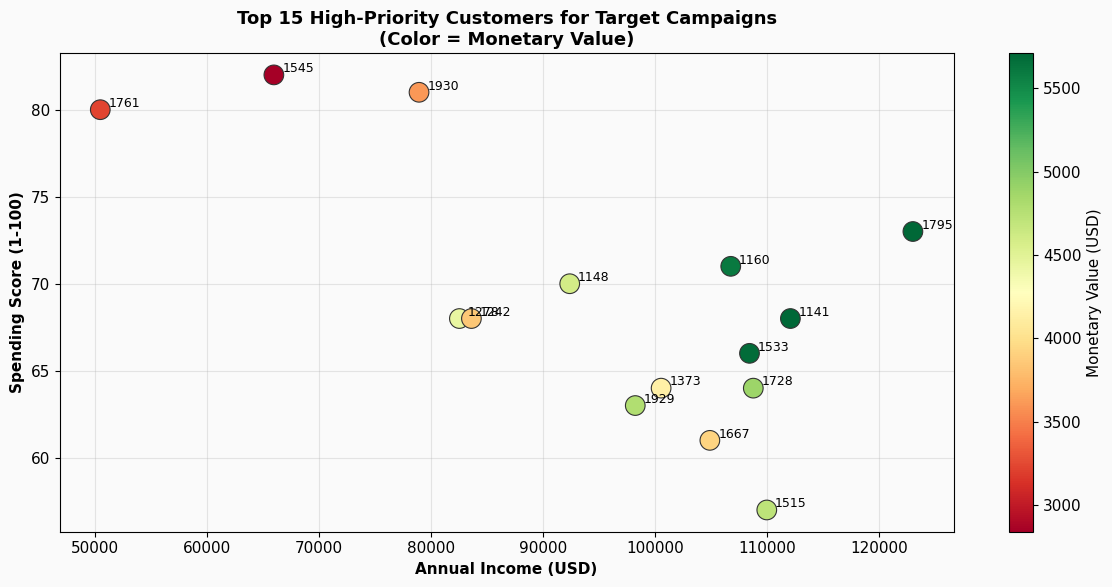

In [26]:
top15 = df_feat.nlargest(15, 'priority_score')

fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(
    top15['Annual_Income'], top15['Spending_Score'],
    c=top15['Monetary'], cmap='RdYlGn', s=200,
    edgecolors='#333', linewidth=0.8, zorder=3
)
plt.colorbar(sc, ax=ax, label='Monetary Value (USD)')

for _, row in top15.iterrows():
    ax.annotate(str(int(row['CustomerID'])), (row['Annual_Income'], row['Spending_Score']),
                textcoords='offset points', xytext=(6, 2), fontsize=9)

ax.set_xlabel('Annual Income (USD)', fontweight='bold')
ax.set_ylabel('Spending Score (1-100)', fontweight='bold')
ax.set_title('Top 15 High-Priority Customers for Target Campaigns\n(Color = Monetary Value)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Model Performance Summary

This section consolidates the classification and clustering metrics for comparison.


In [27]:
summary_data = []

for name, r in results.items():
    cv_mean = cv_results[name].mean()
    cv_std  = cv_results[name].std()
    summary_data.append({
        'Type': 'Classification',
        'Model': name,
        'CV Accuracy': f"{cv_mean:.3f} ± {cv_std:.3f}",
        'Test Accuracy': f"{r['acc']:.3f}",
        'Notes': 'Best' if name == best_name else ''
    })

sil_db_non_noise = silhouette_score(
    X_clust[df_feat['dbscan_cluster'] != -1],
    df_feat.loc[df_feat['dbscan_cluster'] != -1, 'dbscan_cluster']
)
db_db_non_noise = davies_bouldin_score(
    X_clust[df_feat['dbscan_cluster'] != -1],
    df_feat.loc[df_feat['dbscan_cluster'] != -1, 'dbscan_cluster']
)

summary_data.append({
    'Type': 'Clustering', 'Model': f'K-Means (K={OPTIMAL_K})',
    'CV Accuracy': '—',
    'Test Accuracy': f'Sil={sil_km:.3f}, DB={db_km:.3f}',
    'Notes': f'{OPTIMAL_K} distinct groups'
})
summary_data.append({
    'Type': 'Clustering', 'Model': f'DBSCAN (eps={best_params["eps"]:.1f})',
    'CV Accuracy': '—',
    'Test Accuracy': f'Sil={sil_db_non_noise:.3f}, DB={db_db_non_noise:.3f}',
    'Notes': f'{best_params["n_clusters"]} clusters + {best_params["n_noise"]} outliers'
})

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 55)
print("  Final Model Summary")
print("=" * 55)
print(summary_df.to_string(index=False))
print("=" * 55)



  Final Model Summary
          Type               Model   CV Accuracy       Test Accuracy                    Notes
Classification Logistic Regression 0.974 ± 0.011               0.985                     Best
Classification       Random Forest 0.961 ± 0.017               0.970                         
Classification             XGBoost 0.974 ± 0.009               0.985                         
    Clustering       K-Means (K=2)             — Sil=0.253, DB=1.457        2 distinct groups
    Clustering    DBSCAN (eps=1.2)             — Sil=0.277, DB=0.702 2 clusters + 49 outliers


## 11. Conclusion

In this project, customer data was analyzed using both supervised and unsupervised machine learning techniques.
Classification models were trained to predict customer segments, while clustering methods were used to identify groups of customers with similar behavior.
The results can be used to support customer retention, targeted marketing and customer value analysis.
